# Stage 1: Customer Conversion Model
## Will a First-Time Buyer Ever Come Back?

### Motivation
The survival analysis notebook handles one-timers as edge cases: `duration=0` clipped to 1 day, all gap features zeroed. This creates a mass point at t=1 that distorts the Cox PH baseline hazard. The proper approach is a **two-stage model**:
- **Stage 1** (this notebook): Binary classification — will a first-time buyer return?
- **Stage 2** (survival notebook): Survival analysis — for repeat customers only, when will they churn?

### Key Design Principles
1. **No future leakage**: Features extracted from FIRST INVOICE ONLY
2. **Censoring-aware labels**: Customers without enough observation time are excluded
3. **Temporal validation**: Train on earlier cohorts, test on later cohorts

| Part | Description |
|------|-------------|
| **Part 1** | Data Loading & Cleaning |
| **Part 2** | Label Definition with Censoring Handling |
| **Part 3** | First-Invoice Feature Extraction |
| **Part 4** | Temporal Train/Test Split |
| **Part 5** | Model Training (Logistic Regression, Random Forest, XGBoost) |
| **Part 6** | Evaluation: ROC, PR-AUC, Calibration, Lift |
| **Part 7** | Feature Importance Analysis |
| **Part 8** | Error Analysis & Summary |

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

print('All imports loaded.')

All imports loaded.


---
## Part 1: Data Loading & Cleaning
Exact same pipeline as `btyd_analysis/01_data_prep.py` for consistency.

In [2]:
# --- Data Loading & Cleaning ---
df = pd.read_csv('../data/online_retail_II.csv')
print(f'Raw data: {df.shape}')

df = df.dropna(subset=['Customer ID'])
df['Customer ID'] = df['Customer ID'].astype(int)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.drop_duplicates(inplace=True)
df['LineTotal'] = df['Quantity'] * df['Price']

threshold = df['LineTotal'].quantile(0.999)
df = df[df['LineTotal'] <= threshold]

observation_end = df['InvoiceDate'].max()
print(f'Cleaned: {df.shape}')
print(f'Date range: {df["InvoiceDate"].min().date()} to {observation_end.date()}')
print(f'Unique customers: {df["Customer ID"].nunique():,}')

Raw data: (1067371, 8)


Cleaned: (778649, 9)
Date range: 2009-12-01 to 2011-12-09
Unique customers: 5,867


---
## Part 2: Label Definition with Censoring Handling

### The Censoring Problem
A customer whose first purchase was Nov 30, 2011 has only **9 days** of observation before the dataset ends. If they haven't returned, we **cannot** label them as a one-timer — they simply haven't had enough time.

### Solution: 90-Day Observation Window
The churn-window analysis showed 45 days captures only 67% of first returns. We use **90 days** (captures ~83%) as a more conservative threshold for a permanent binary label.

| Label | Condition |
|-------|----------|
| `y=1` (repeater) | Made 2+ purchases (regardless of gap) |
| `y=0` (one-timer) | Only 1 purchase AND ≥90 days of observation |
| `excluded` | Only 1 purchase AND <90 days observation → **censored** |

In [3]:
# --- Label Definition ---
OBSERVATION_WINDOW = 90  # days

# Get first and second purchase date per customer (at invoice level)
invoice_dates = (
    df.groupby(['Customer ID', 'Invoice'])['InvoiceDate']
    .min().reset_index()
    .sort_values(['Customer ID', 'InvoiceDate'])
)

customer_purchases = invoice_dates.groupby('Customer ID').agg(
    first_purchase_date=('InvoiceDate', 'first'),
    second_purchase_date=('InvoiceDate', lambda x: x.iloc[1] if len(x) > 1 else pd.NaT),
    total_invoices=('Invoice', 'count')
).reset_index()

# Observation days available after first purchase
customer_purchases['obs_days'] = (
    observation_end - customer_purchases['first_purchase_date']
).dt.days

# Days to second purchase
customer_purchases['days_to_second'] = (
    customer_purchases['second_purchase_date'] - customer_purchases['first_purchase_date']
).dt.days

# Label logic
customer_purchases['label'] = np.where(
    customer_purchases['total_invoices'] > 1, 1,          # returned = repeater
    np.where(
        customer_purchases['obs_days'] >= OBSERVATION_WINDOW, 0,  # enough time, didn't return
        -1  # censored
    )
)

labeled = customer_purchases[customer_purchases['label'] >= 0].copy()
censored = customer_purchases[customer_purchases['label'] == -1]

print(f'=== Label Distribution ===')
print(f'Total customers:      {len(customer_purchases):,}')
print(f'Labeled (usable):     {len(labeled):,} ({len(labeled)/len(customer_purchases)*100:.1f}%)')
print(f'  Repeaters (y=1):    {(labeled["label"]==1).sum():,} ({(labeled["label"]==1).mean()*100:.1f}%)')
print(f'  One-timers (y=0):   {(labeled["label"]==0).sum():,} ({(1-labeled["label"]).mean()*100:.1f}%)')
print(f'Censored (excluded):  {len(censored):,}')
if len(censored) > 0:
    print(f'  First purchase range: {censored["first_purchase_date"].min().date()} to {censored["first_purchase_date"].max().date()}')

=== Label Distribution ===
Total customers:      5,867
Labeled (usable):     5,501 (93.8%)
  Repeaters (y=1):    4,243 (77.1%)
  One-timers (y=0):   1,258 (22.9%)
Censored (excluded):  366
  First purchase range: 2011-09-11 to 2011-12-09


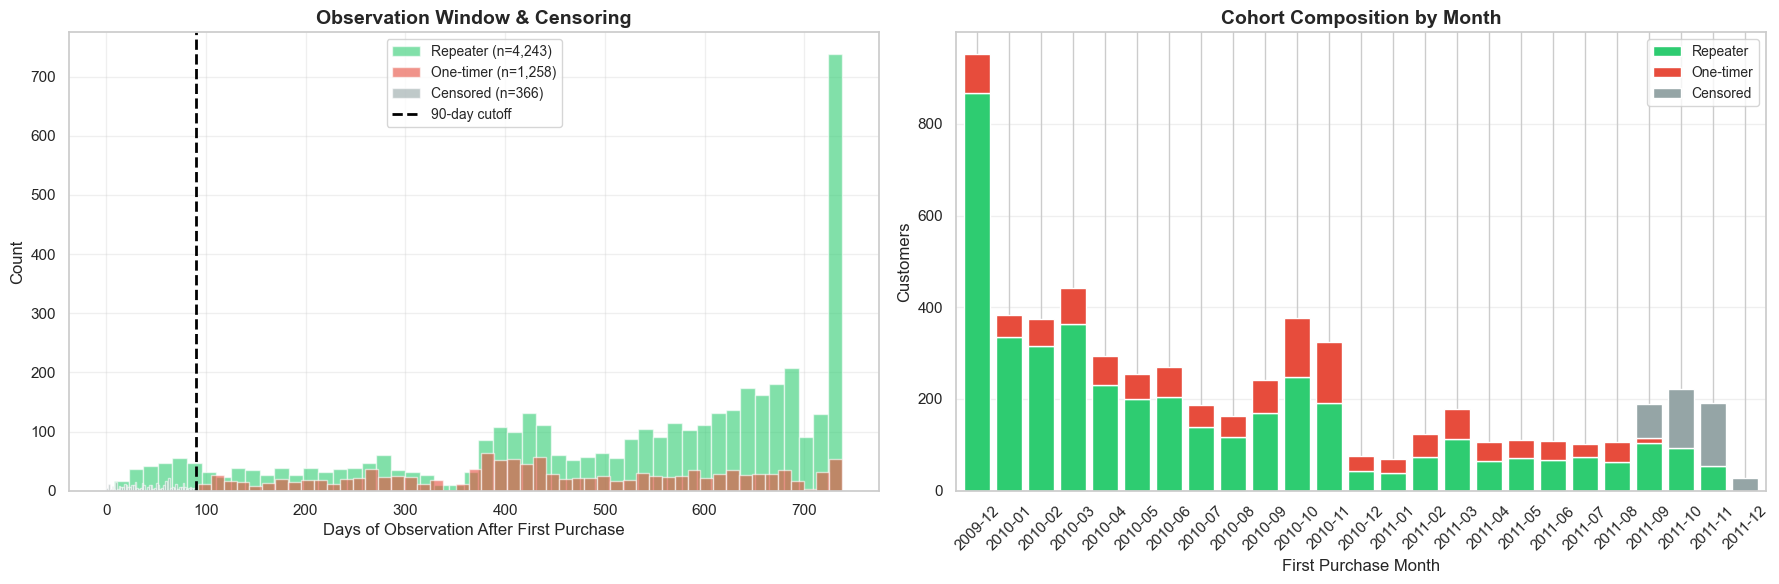

In [4]:
# --- Label Diagnostics ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: observation days histogram with cutoff
ax = axes[0]
colors_label = {1: '#2ecc71', 0: '#e74c3c', -1: '#95a5a6'}
for lbl, name in [(1, 'Repeater'), (0, 'One-timer'), (-1, 'Censored')]:
    subset = customer_purchases[customer_purchases['label'] == lbl]
    ax.hist(subset['obs_days'], bins=50, alpha=0.6, label=f'{name} (n={len(subset):,})',
            color=colors_label[lbl], edgecolor='white')
ax.axvline(OBSERVATION_WINDOW, color='black', linestyle='--', linewidth=2, label=f'{OBSERVATION_WINDOW}-day cutoff')
ax.set_xlabel('Days of Observation After First Purchase', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Observation Window & Censoring', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: label composition by first-purchase month
ax = axes[1]
cp = customer_purchases.copy()
cp['month'] = cp['first_purchase_date'].dt.to_period('M')
monthly = cp.groupby(['month', 'label']).size().unstack(fill_value=0)
monthly.columns = [['Censored', 'One-timer', 'Repeater'][int(c)+1] for c in monthly.columns]
monthly = monthly[['Repeater', 'One-timer', 'Censored']]
monthly.plot(kind='bar', stacked=True, ax=ax,
             color=['#2ecc71', '#e74c3c', '#95a5a6'], edgecolor='white', width=0.8)
ax.set_xlabel('First Purchase Month', fontsize=12)
ax.set_ylabel('Customers', fontsize=12)
ax.set_title('Cohort Composition by Month', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## Part 3: First-Invoice Feature Extraction

**Critical constraint:** Features extracted from the customer's **first invoice ONLY**. No information from future purchases. This ensures the model can score a customer the moment they make their first purchase.

| Group | Features |
|-------|----------|
| Monetary | `first_total_spend_log`, `first_avg_price`, `first_max_price`, `first_price_range`, `first_price_std` |
| Basket | `first_num_lines`, `first_unique_items`, `first_total_qty`, `first_qty_per_unique` |
| Concentration | `first_spend_concentration` (Herfindahl) |
| Temporal | `first_hour`, `first_day_of_week`, `first_is_weekend`, `first_month`, `first_is_holiday_season` |
| Geographic | `is_uk`, `country_group` (one-hot) |
| Product | `has_christmas`, `has_gift`, `has_vintage`, `has_heart`, `first_desc_diversity` |

In [5]:
# --- First-Invoice Feature Extraction ---

# Find each customer's first invoice
first_invoice_id = (
    invoice_dates.groupby('Customer ID')
    .first()
    .reset_index()[['Customer ID', 'Invoice']]
)

# Get all line items from first invoice only
first_lines = df.merge(first_invoice_id, on=['Customer ID', 'Invoice'], how='inner')
print(f'First-invoice line items: {len(first_lines):,}')
print(f'Customers: {first_lines["Customer ID"].nunique():,}')

# ── Monetary features ──
monetary = first_lines.groupby('Customer ID').agg(
    first_total_spend=('LineTotal', 'sum'),
    first_avg_price=('Price', 'mean'),
    first_max_price=('Price', 'max'),
    first_min_price=('Price', 'min'),
    first_price_std=('Price', 'std'),
)
monetary['first_price_std'] = monetary['first_price_std'].fillna(0)
monetary['first_price_range'] = monetary['first_max_price'] - monetary['first_min_price']
monetary['first_total_spend_log'] = np.log1p(monetary['first_total_spend'])

# ── Basket features ──
basket = first_lines.groupby('Customer ID').agg(
    first_num_lines=('StockCode', 'count'),
    first_unique_items=('StockCode', 'nunique'),
    first_total_qty=('Quantity', 'sum'),
    first_avg_qty=('Quantity', 'mean'),
)
basket['first_qty_per_unique'] = basket['first_total_qty'] / basket['first_unique_items']

# ── Spend concentration (Herfindahl index) ──
def herfindahl(group):
    total = group['LineTotal'].sum()
    if total == 0:
        return 1.0
    shares = group['LineTotal'] / total
    return (shares ** 2).sum()

spend_conc = first_lines.groupby('Customer ID').apply(herfindahl)
spend_conc.name = 'first_spend_concentration'

# ── Temporal features ──
first_dates = first_lines.groupby('Customer ID')['InvoiceDate'].first()
temporal = pd.DataFrame({
    'first_hour': first_dates.dt.hour,
    'first_day_of_week': first_dates.dt.dayofweek,
    'first_is_weekend': first_dates.dt.dayofweek.isin([5, 6]).astype(int),
    'first_month': first_dates.dt.month,
    'first_is_holiday_season': first_dates.dt.month.isin([11, 12]).astype(int),
}, index=first_dates.index)

# ── Geographic features ──
country = first_lines.groupby('Customer ID')['Country'].first()
geo = pd.DataFrame({'Country': country})
geo['is_uk'] = (geo['Country'] == 'United Kingdom').astype(int)

europe_major = {'Germany', 'France', 'Netherlands', 'Spain', 'Belgium', 'Switzerland',
                'Portugal', 'Italy', 'Austria', 'Sweden', 'Norway', 'Denmark', 'Finland'}
geo['country_group'] = np.where(
    geo['Country'] == 'United Kingdom', 'UK',
    np.where(geo['Country'].isin(europe_major), 'Europe_Major',
    np.where(geo['Country'].isin(['EIRE', 'Channel Islands', 'Iceland']), 'Europe_Other',
    'Non_Europe'))
)
country_dummies = pd.get_dummies(geo['country_group'], prefix='geo', drop_first=True)

# ── Product/Description features ──
desc = first_lines.copy()
desc['Description'] = desc['Description'].fillna('').str.upper()

product_flags = desc.groupby('Customer ID').agg(
    has_christmas=('Description', lambda x: int(x.str.contains('CHRISTMAS|XMAS|NOEL').any())),
    has_gift=('Description', lambda x: int(x.str.contains('GIFT|PRESENT|WRAP').any())),
    has_vintage=('Description', lambda x: int(x.str.contains('VINTAGE|RETRO').any())),
    has_heart=('Description', lambda x: int(x.str.contains('HEART|LOVE').any())),
)

desc_diversity = (
    desc.groupby('Customer ID')['Description']
    .apply(lambda x: x.str.split().str[0].nunique())
)
desc_diversity.name = 'first_desc_diversity'

# ── Assemble feature matrix ──
features = (
    monetary
    .join(basket)
    .join(spend_conc)
    .join(temporal)
    .join(country_dummies)
    .join(geo[['is_uk']])
    .join(product_flags)
    .join(desc_diversity)
)

# Drop raw monetary (keep log version), drop min_price (redundant with range)
features = features.drop(columns=['first_total_spend', 'first_min_price'], errors='ignore')

# Merge with labels
model_df = features.join(
    labeled.set_index('Customer ID')[['label', 'first_purchase_date']], how='inner'
)
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

print(f'\nFinal model dataset: {len(model_df):,} customers x {model_df.shape[1]} columns')
print(f'Repeaters (y=1): {(model_df["label"]==1).sum():,} ({(model_df["label"]==1).mean()*100:.1f}%)')
print(f'One-timers (y=0): {(model_df["label"]==0).sum():,} ({(1-model_df["label"]).mean()*100:.1f}%)')
print(f'\nFeatures ({model_df.shape[1]-2}):')
feature_cols = [c for c in model_df.columns if c not in ['label', 'first_purchase_date']]
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {c}')

First-invoice line items: 143,546
Customers: 5,867



Final model dataset: 5,501 customers x 27 columns
Repeaters (y=1): 4,243 (77.1%)
One-timers (y=0): 1,258 (22.9%)

Features (25):
   1. first_avg_price
   2. first_max_price
   3. first_price_std
   4. first_price_range
   5. first_total_spend_log
   6. first_num_lines
   7. first_unique_items
   8. first_total_qty
   9. first_avg_qty
  10. first_qty_per_unique
  11. first_spend_concentration
  12. first_hour
  13. first_day_of_week
  14. first_is_weekend
  15. first_month
  16. first_is_holiday_season
  17. geo_Europe_Other
  18. geo_Non_Europe
  19. geo_UK
  20. is_uk
  21. has_christmas
  22. has_gift
  23. has_vintage
  24. has_heart
  25. first_desc_diversity


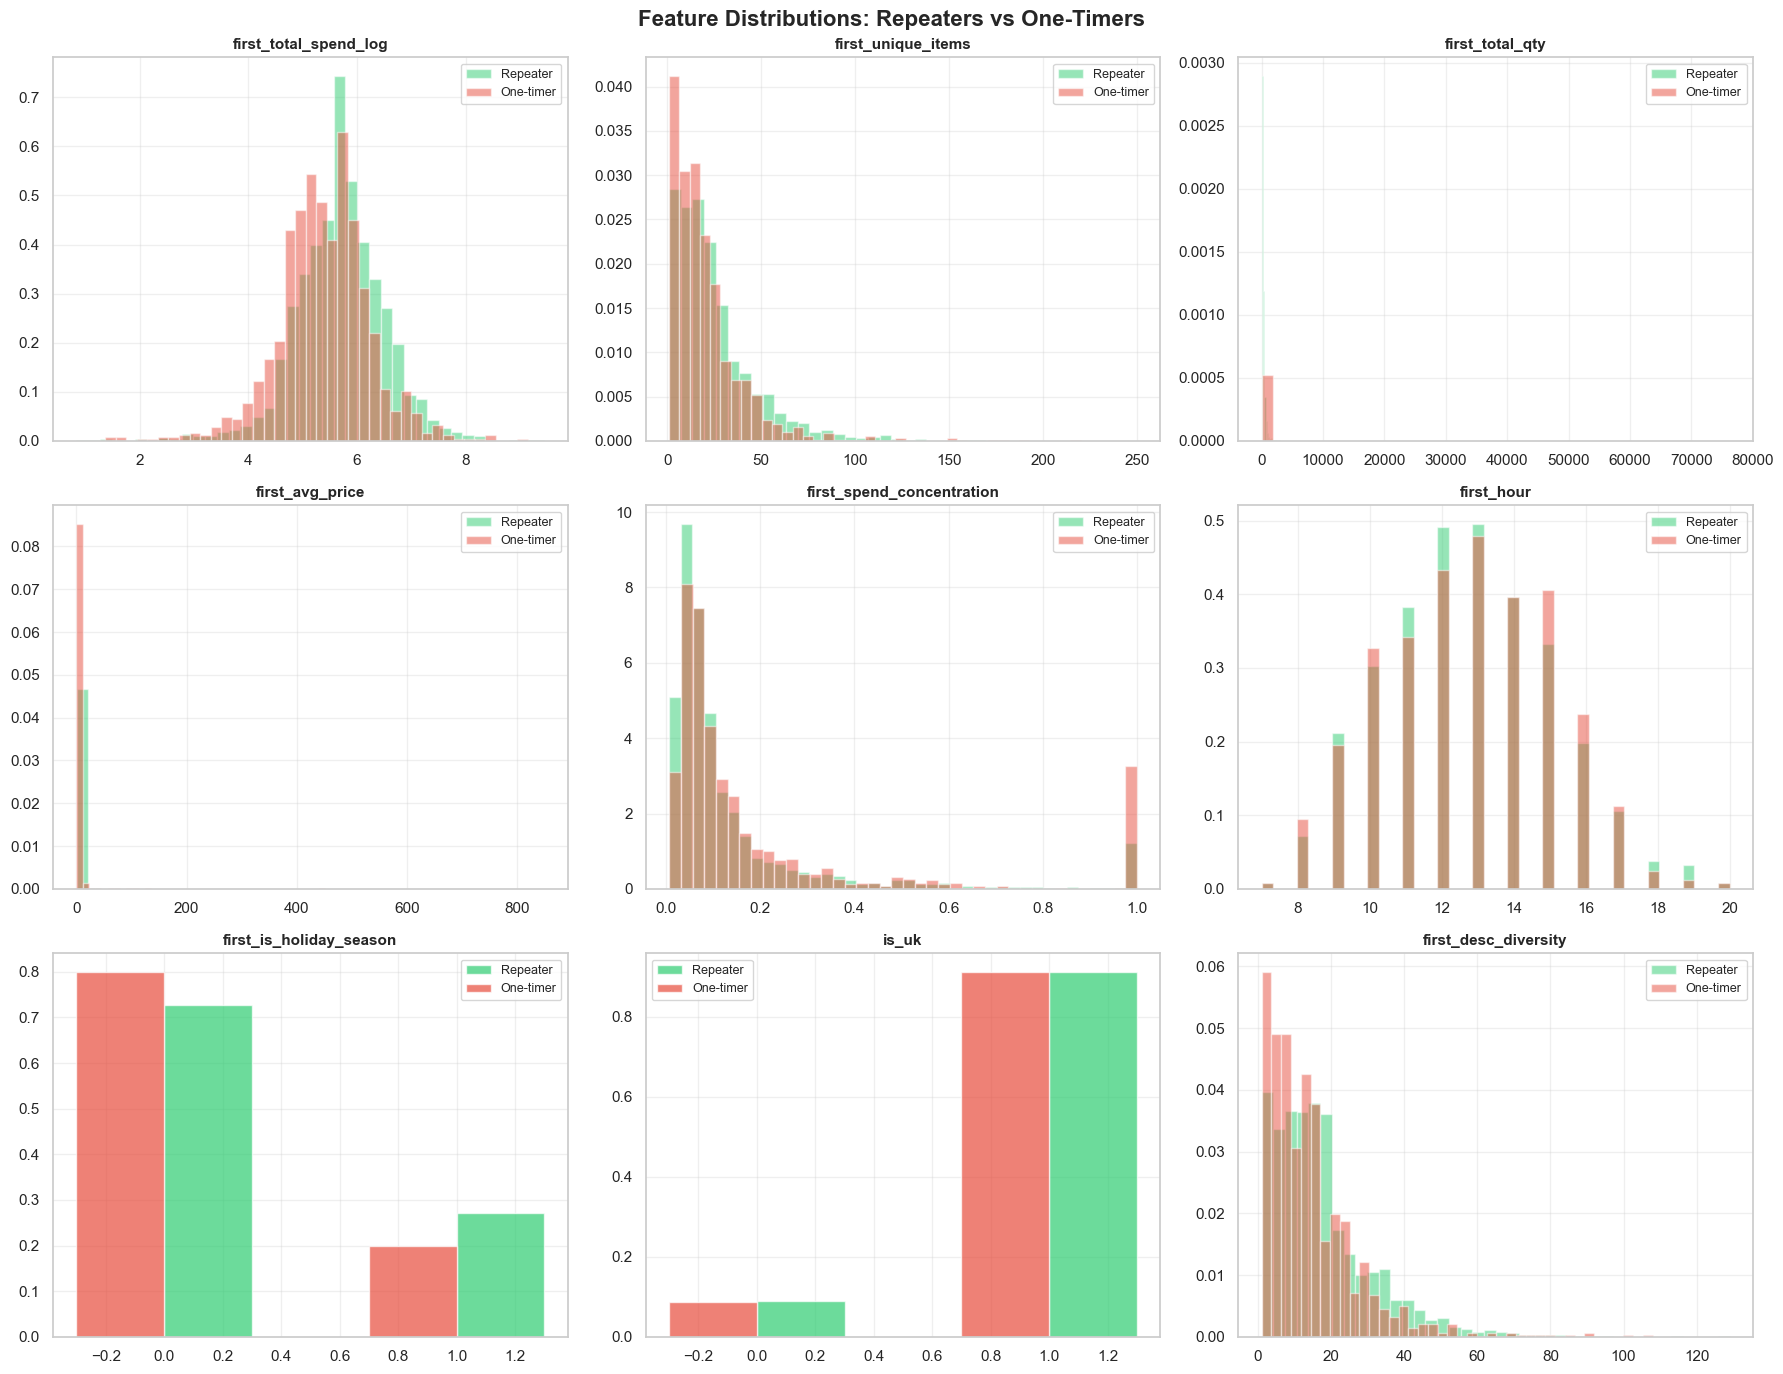

In [6]:
# --- Feature Distributions by Label ---
plot_features = [
    'first_total_spend_log', 'first_unique_items', 'first_total_qty',
    'first_avg_price', 'first_spend_concentration', 'first_hour',
    'first_is_holiday_season', 'is_uk', 'first_desc_diversity'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, feat in enumerate(plot_features):
    ax = axes[i]
    for lbl, name, color in [(1, 'Repeater', '#2ecc71'), (0, 'One-timer', '#e74c3c')]:
        data = model_df[model_df['label'] == lbl][feat]
        if data.nunique() <= 5:  # categorical-like
            vals, counts = np.unique(data, return_counts=True)
            ax.bar(vals + (0.15 if lbl == 1 else -0.15), counts / counts.sum(),
                   width=0.3, alpha=0.7, label=name, color=color, edgecolor='white')
        else:
            ax.hist(data, bins=40, alpha=0.5, label=name, color=color,
                    edgecolor='white', density=True)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions: Repeaters vs One-Timers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 4: Temporal Train/Test Split

**Why temporal, not random?** Random splits leak temporal patterns (seasonality, company growth). A model must generalize to *future* customers, not randomly held-out past customers.

| Set | First Purchase Range | Min Observation |
|-----|---------------------|-----------------|
| Train | Before 2011-06-01 | 192+ days |
| Test | 2011-06-01 to 2011-09-10 | 90+ days |
| Excluded | After 2011-09-10 (no second purchase) | <90 days (censored) |

In [7]:
# --- Temporal Train/Test Split ---
TRAIN_CUTOFF = pd.Timestamp('2011-06-01')
TEST_CUTOFF = observation_end - pd.Timedelta(days=OBSERVATION_WINDOW)

train_mask = model_df['first_purchase_date'] < TRAIN_CUTOFF
test_mask = (model_df['first_purchase_date'] >= TRAIN_CUTOFF) & \
            (model_df['first_purchase_date'] <= TEST_CUTOFF)

train_df = model_df[train_mask].copy()
test_df = model_df[test_mask].copy()

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_test = test_df[feature_cols].values
y_test = test_df['label'].values

# Sanity: no temporal overlap
assert train_df['first_purchase_date'].max() < test_df['first_purchase_date'].min(), \
    'Temporal leak!'

print(f'Train: {len(train_df):,} customers ({y_train.mean()*100:.1f}% repeaters)')
print(f'  First purchase: {train_df["first_purchase_date"].min().date()} to {train_df["first_purchase_date"].max().date()}')
print(f'Test:  {len(test_df):,} customers ({y_test.mean()*100:.1f}% repeaters)')
print(f'  First purchase: {test_df["first_purchase_date"].min().date()} to {test_df["first_purchase_date"].max().date()}')
print(f'\nNo temporal overlap: PASS')

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: 4,924 customers (76.9% repeaters)
  First purchase: 2009-12-01 to 2011-05-31
Test:  348 customers (64.9% repeaters)
  First purchase: 2011-06-01 to 2011-09-09

No temporal overlap: PASS


---
## Part 5: Model Training

Three models with increasing complexity:
1. **Logistic Regression** — interpretable baseline, L2 regularization, scaled features
2. **Random Forest** — non-linear, handles interactions, `class_weight='balanced'`
3. **XGBoost** — gradient boosting, `scale_pos_weight`, early stopping

In [8]:
# --- Logistic Regression ---
lr = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_proba_train = lr.predict_proba(X_train_scaled)[:, 1]
lr_proba_test = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(f'  Train AUC-ROC: {roc_auc_score(y_train, lr_proba_train):.4f}')
print(f'  Test  AUC-ROC: {roc_auc_score(y_test, lr_proba_test):.4f}')
print(f'  Test  PR-AUC:  {average_precision_score(y_test, lr_proba_test):.4f}')

# Top coefficients
lr_coefs = pd.Series(lr.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
print(f'\nTop 10 coefficients (absolute):')
for feat, coef in lr_coefs.head(10).items():
    direction = 'more likely to return' if coef > 0 else 'less likely to return'
    print(f'  {feat:35s} {coef:+.4f}  ({direction})')

=== Logistic Regression ===
  Train AUC-ROC: 0.6421
  Test  AUC-ROC: 0.5877
  Test  PR-AUC:  0.7094

Top 10 coefficients (absolute):
  first_max_price                     +0.7398  (more likely to return)
  first_avg_price                     -0.6731  (less likely to return)
  first_num_lines                     -0.5564  (less likely to return)
  first_price_range                   -0.5217  (less likely to return)
  first_unique_items                  +0.4523  (more likely to return)
  first_total_spend_log               +0.3656  (more likely to return)
  first_is_holiday_season             +0.3347  (more likely to return)
  first_month                         -0.1916  (less likely to return)
  first_desc_diversity                +0.1683  (more likely to return)
  has_heart                           +0.1438  (more likely to return)


In [9]:
# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=500, max_depth=8, min_samples_leaf=20,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_proba_train = rf.predict_proba(X_train)[:, 1]
rf_proba_test = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'  Train AUC-ROC: {roc_auc_score(y_train, rf_proba_train):.4f}')
print(f'  Test  AUC-ROC: {roc_auc_score(y_test, rf_proba_test):.4f}')
print(f'  Test  PR-AUC:  {average_precision_score(y_test, rf_proba_test):.4f}')

=== Random Forest ===
  Train AUC-ROC: 0.7954
  Test  AUC-ROC: 0.6138
  Test  PR-AUC:  0.7403


In [10]:
# --- XGBoost ---
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=10, gamma=1,
    scale_pos_weight=neg_count / pos_count,
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42, n_jobs=-1, verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_proba_train = xgb_model.predict_proba(X_train)[:, 1]
xgb_proba_test = xgb_model.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(f'  Train AUC-ROC: {roc_auc_score(y_train, xgb_proba_train):.4f}')
print(f'  Test  AUC-ROC: {roc_auc_score(y_test, xgb_proba_test):.4f}')
print(f'  Test  PR-AUC:  {average_precision_score(y_test, xgb_proba_test):.4f}')
print(f'  Best iteration: {xgb_model.best_iteration}')

=== XGBoost ===
  Train AUC-ROC: 0.7348
  Test  AUC-ROC: 0.6204
  Test  PR-AUC:  0.7446
  Best iteration: 26


In [11]:
# --- Model Comparison Table ---
all_models = {
    'Logistic Regression': lr_proba_test,
    'Random Forest': rf_proba_test,
    'XGBoost': xgb_proba_test,
}

results = []
for name, proba in all_models.items():
    pred = (proba >= 0.5).astype(int)
    results.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
        'Brier Score': brier_score_loss(y_test, proba),
        'F1': f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('='*75)
print('MODEL COMPARISON (Test Set)')
print('='*75)
print(results_df.round(4).to_string())

MODEL COMPARISON (Test Set)
                     AUC-ROC  PR-AUC  Brier Score      F1  Precision  Recall
Model                                                                       
Logistic Regression   0.5877  0.7094       0.2283  0.7873     0.6531  0.9912
Random Forest         0.6138  0.7403       0.2398  0.6635     0.7263  0.6106
XGBoost               0.6204  0.7446       0.2461  0.5753     0.7329  0.4735


---
## Part 6: Comprehensive Evaluation

1. **ROC Curves** — discrimination ability
2. **Precision-Recall Curves** — more informative under class imbalance
3. **Calibration Plot** — are predicted probabilities reliable?
4. **Lift Chart** — operational value: how much better than random?
5. **Confusion Matrices** — at optimal threshold (Youden's J)

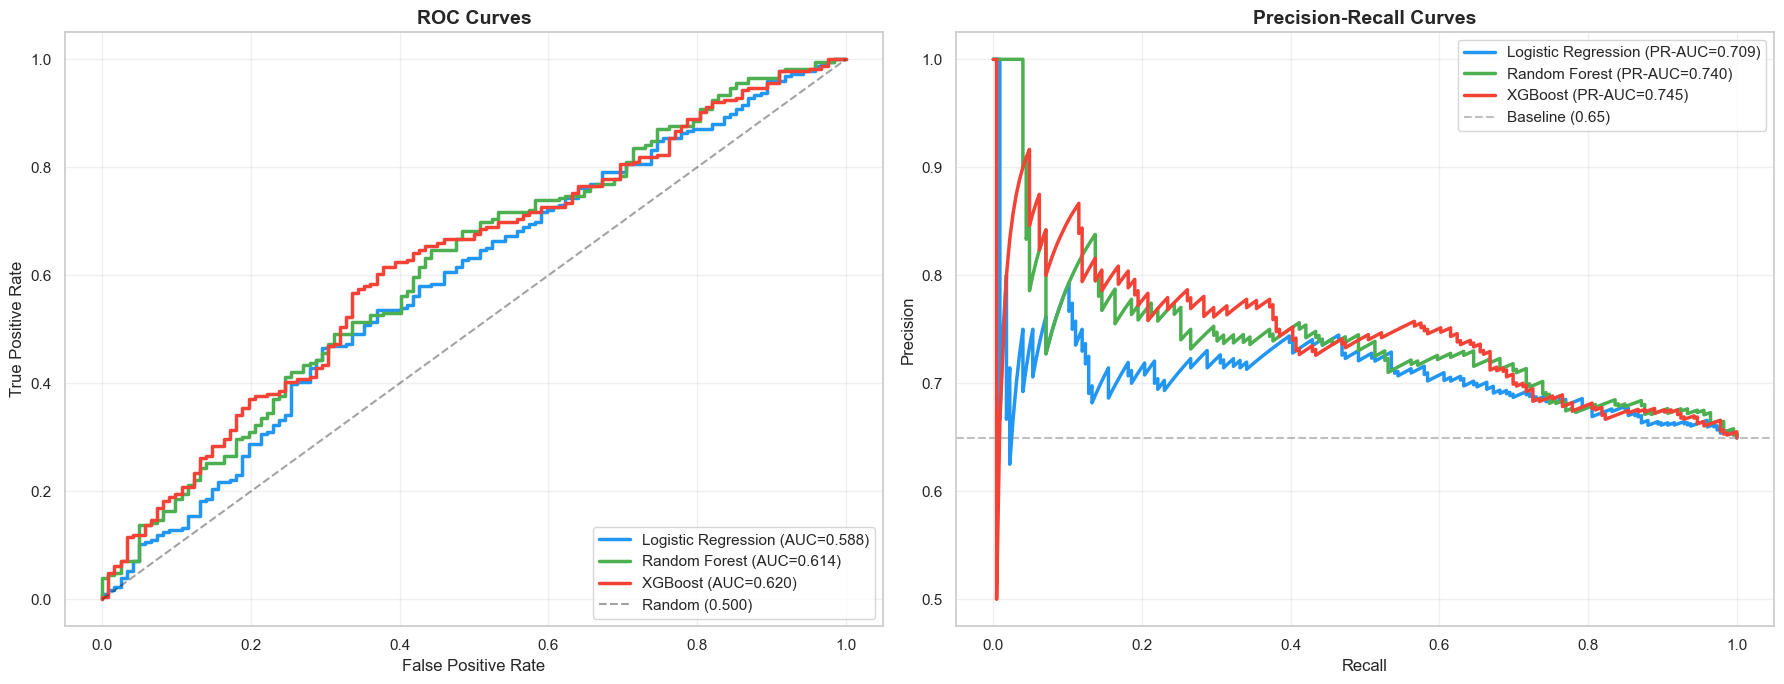

In [12]:
# --- ROC and Precision-Recall Curves ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = {'Logistic Regression': '#2196F3', 'Random Forest': '#4CAF50', 'XGBoost': '#F44336'}

# ROC
ax = axes[0]
for name, proba in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=colors[name], linewidth=2.5, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

# PR
ax = axes[1]
baseline = y_test.mean()
for name, proba in all_models.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=colors[name], linewidth=2.5, label=f'{name} (PR-AUC={pr_auc:.3f})')
ax.axhline(baseline, color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

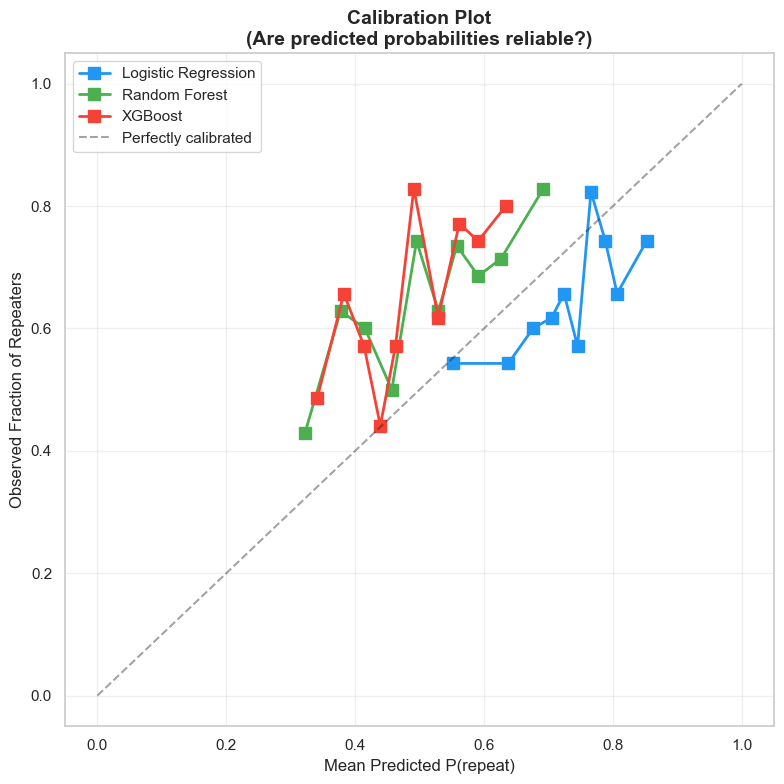

In [13]:
# --- Calibration Plot ---
fig, ax = plt.subplots(figsize=(8, 8))

for name, proba in all_models.items():
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    ax.plot(prob_pred, prob_true, 's-', color=colors[name], linewidth=2,
            markersize=8, label=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfectly calibrated')
ax.set_xlabel('Mean Predicted P(repeat)', fontsize=12)
ax.set_ylabel('Observed Fraction of Repeaters', fontsize=12)
ax.set_title('Calibration Plot\n(Are predicted probabilities reliable?)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

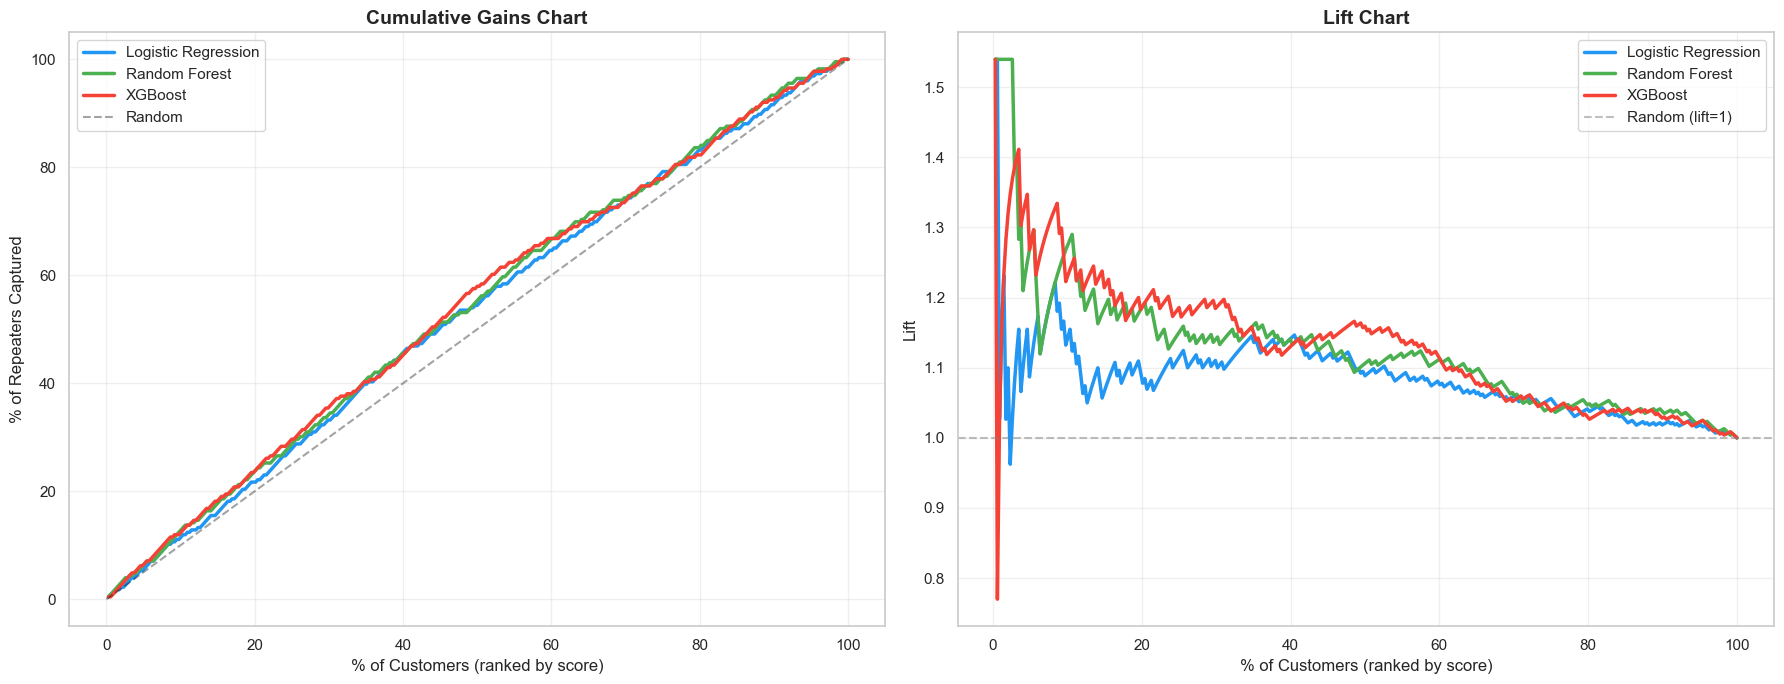

In [14]:
# --- Lift Chart ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for name, proba in all_models.items():
    sorted_idx = np.argsort(-proba)
    sorted_labels = y_test[sorted_idx]
    n = len(sorted_labels)
    cum_positives = np.cumsum(sorted_labels)
    total_positives = sorted_labels.sum()
    percentiles = np.arange(1, n + 1) / n
    gains = cum_positives / total_positives

    # Cumulative gains
    axes[0].plot(percentiles * 100, gains * 100, color=colors[name],
                 linewidth=2.5, label=name)

    # Lift
    lift = gains / percentiles
    axes[1].plot(percentiles * 100, lift, color=colors[name],
                 linewidth=2.5, label=name)

axes[0].plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('% of Customers (ranked by score)', fontsize=12)
axes[0].set_ylabel('% of Repeaters Captured', fontsize=12)
axes[0].set_title('Cumulative Gains Chart', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1, color='gray', linestyle='--', alpha=0.5, label='Random (lift=1)')
axes[1].set_xlabel('% of Customers (ranked by score)', fontsize=12)
axes[1].set_ylabel('Lift', fontsize=12)
axes[1].set_title('Lift Chart', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

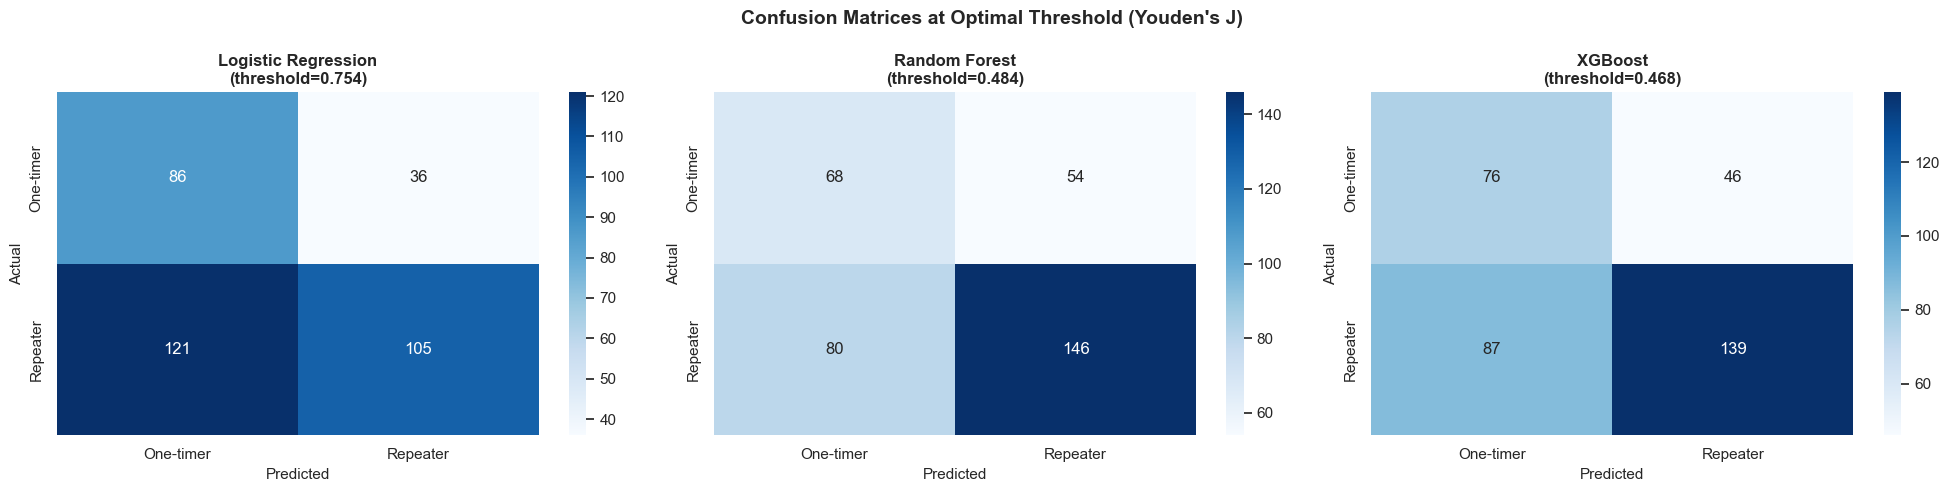

In [15]:
# --- Confusion Matrices at Optimal Threshold (Youden's J) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

optimal_thresholds = {}
for idx, (name, proba) in enumerate(all_models.items()):
    fpr, tpr, thresholds = roc_curve(y_test, proba)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    optimal_thresholds[name] = best_threshold

    pred = (proba >= best_threshold).astype(int)
    cm = confusion_matrix(y_test, pred)

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['One-timer', 'Repeater'],
                yticklabels=['One-timer', 'Repeater'])
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{name}\n(threshold={best_threshold:.3f})', fontweight='bold')

plt.suptitle('Confusion Matrices at Optimal Threshold (Youden\'s J)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 7: Feature Importance Analysis

Three perspectives on what drives first-purchase conversion:
1. **Logistic Regression** — coefficient magnitude (after scaling)
2. **Random Forest** — Gini impurity importance
3. **XGBoost** — gain-based importance

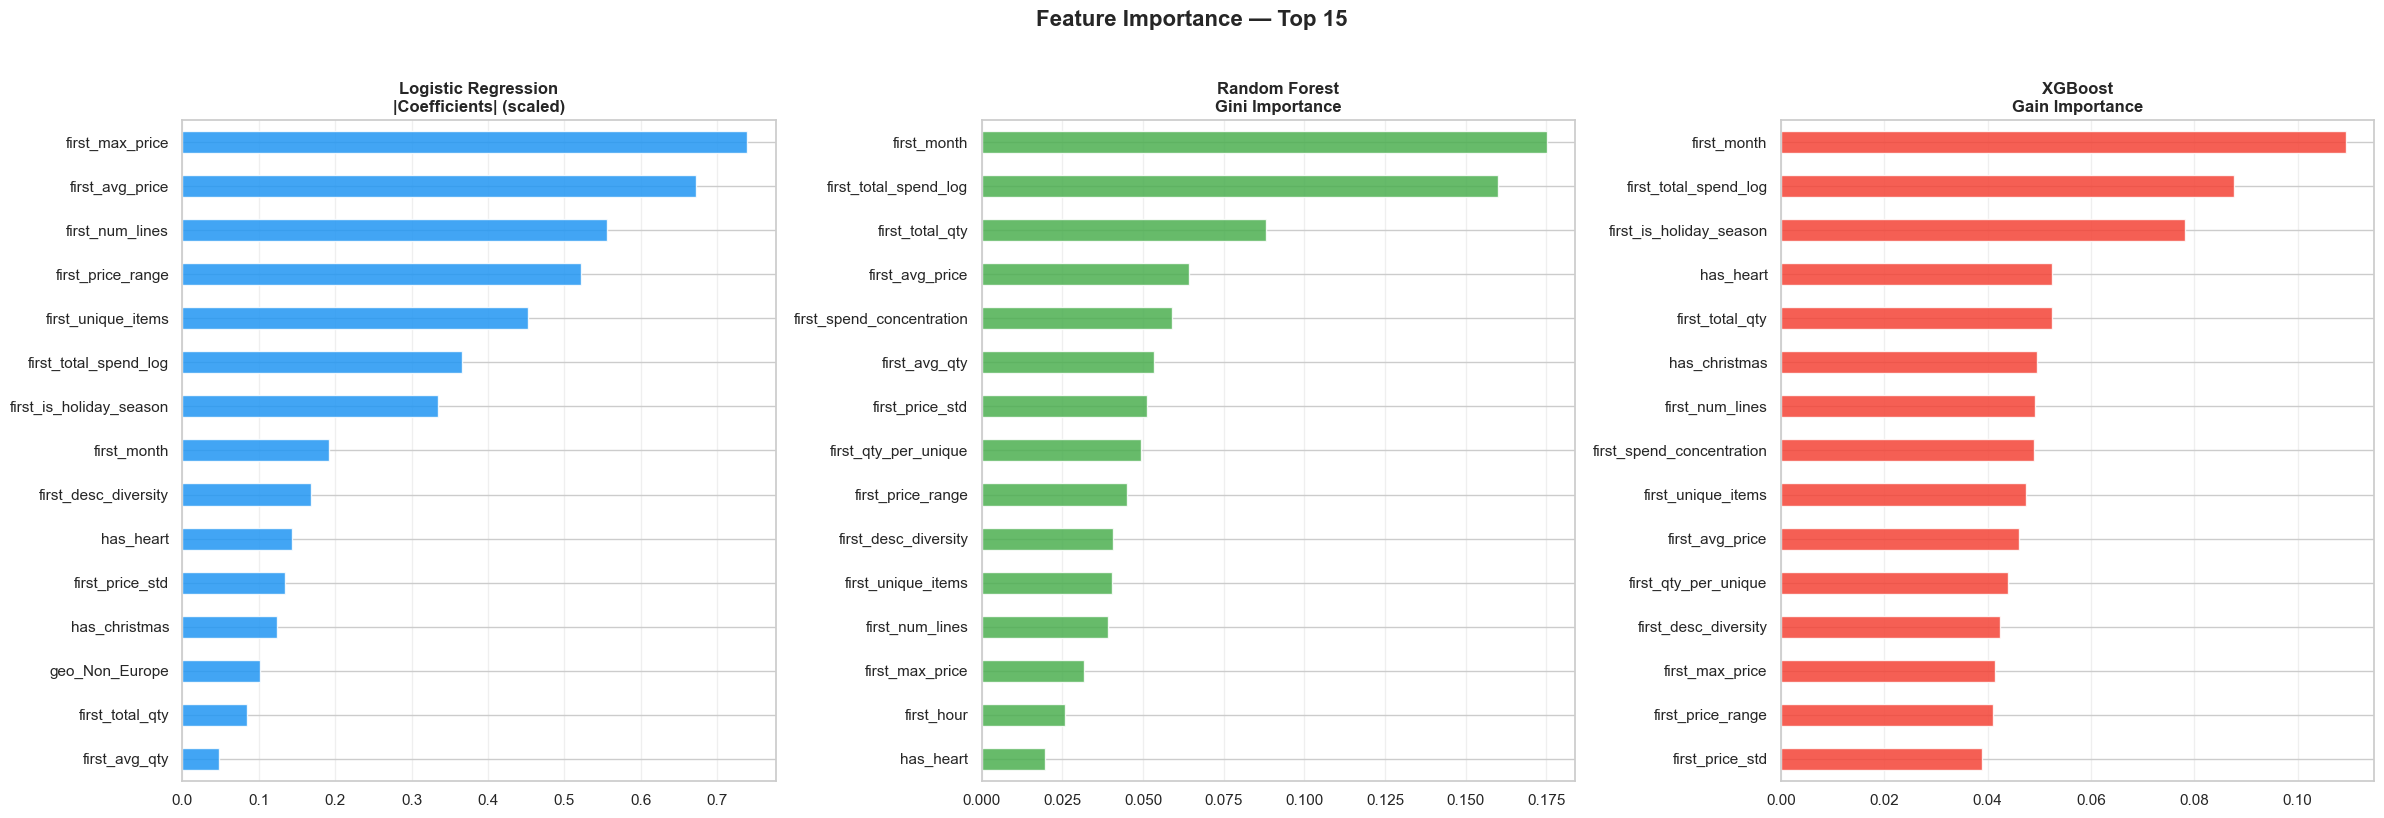


Consensus features (top 10 in all 3 models): ['first_avg_price', 'first_month', 'first_total_spend_log']


In [16]:
# --- Feature Importance Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
top_n = 15

# LR coefficients
lr_imp = pd.Series(np.abs(lr.coef_[0]), index=feature_cols).sort_values(ascending=True)
lr_imp.tail(top_n).plot.barh(ax=axes[0], color='#2196F3', alpha=0.85, edgecolor='white')
axes[0].set_title('Logistic Regression\n|Coefficients| (scaled)', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# RF importance
rf_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
rf_imp.tail(top_n).plot.barh(ax=axes[1], color='#4CAF50', alpha=0.85, edgecolor='white')
axes[1].set_title('Random Forest\nGini Importance', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

# XGBoost importance
xgb_imp = pd.Series(
    xgb_model.feature_importances_, index=feature_cols
).sort_values(ascending=True)
xgb_imp.tail(top_n).plot.barh(ax=axes[2], color='#F44336', alpha=0.85, edgecolor='white')
axes[2].set_title('XGBoost\nGain Importance', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Importance — Top 15', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Consensus top features (appear in top 10 of all 3 models)
top10_lr = set(lr_imp.tail(10).index)
top10_rf = set(rf_imp.tail(10).index)
top10_xgb = set(xgb_imp.tail(10).index)
consensus = top10_lr & top10_rf & top10_xgb
print(f'\nConsensus features (top 10 in all 3 models): {sorted(consensus)}')

---
## Part 8: Error Analysis & Summary

In [17]:
# --- Error Analysis (using best model's optimal threshold) ---
# Use XGBoost as representative
best_proba = xgb_proba_test
best_thresh = optimal_thresholds['XGBoost']
best_pred = (best_proba >= best_thresh).astype(int)

test_analysis = test_df[feature_cols].copy()
test_analysis['actual'] = y_test
test_analysis['predicted'] = best_pred
test_analysis['proba'] = best_proba

# Classification categories
test_analysis['category'] = np.where(
    (test_analysis['actual'] == 1) & (test_analysis['predicted'] == 1), 'True Positive',
    np.where(
        (test_analysis['actual'] == 0) & (test_analysis['predicted'] == 0), 'True Negative',
        np.where(
            (test_analysis['actual'] == 1) & (test_analysis['predicted'] == 0), 'False Negative',
            'False Positive'
        )
    )
)

print('=== Error Analysis (XGBoost) ===')
print(test_analysis['category'].value_counts().to_string())

# Compare feature means across error categories
key_features = ['first_total_spend_log', 'first_unique_items', 'first_total_qty',
                'first_spend_concentration', 'is_uk', 'first_is_holiday_season']

print(f'\n--- Feature Means by Classification Category ---')
error_profiles = test_analysis.groupby('category')[key_features].mean().round(3)
print(error_profiles.to_string())

# Most confident wrong predictions
fn = test_analysis[test_analysis['category'] == 'False Negative'].sort_values('proba')
fp = test_analysis[test_analysis['category'] == 'False Positive'].sort_values('proba', ascending=False)

print(f'\n--- Most Confident False Negatives (predicted one-timer, actually returned) ---')
print(f'  n={len(fn)}, mean P(repeat)={fn["proba"].mean():.3f}')
print(f'  These are missed retention opportunities.')

print(f'\n--- Most Confident False Positives (predicted repeater, never returned) ---')
print(f'  n={len(fp)}, mean P(repeat)={fp["proba"].mean():.3f}')
print(f'  These would waste retention campaign budget.')

=== Error Analysis (XGBoost) ===
category
True Positive     139
False Negative     87
True Negative      76
False Positive     46

--- Feature Means by Classification Category ---
                first_total_spend_log  first_unique_items  first_total_qty  first_spend_concentration  is_uk  first_is_holiday_season
category                                                                                                                             
False Negative                  5.003              14.563          106.207                      0.185  0.943                      0.0
False Positive                  6.198              37.630          376.739                      0.081  0.804                      0.0
True Negative                   4.989              12.158          130.171                      0.271  0.921                      0.0
True Positive                   6.127              35.237          343.475                      0.073  0.770                      0.0

--- Most Confid

In [18]:
# --- Sensitivity Analysis: Different Observation Windows ---
windows = [45, 60, 90, 120]
sensitivity = []

for w in windows:
    cp = customer_purchases.copy()
    cp['label_w'] = np.where(
        cp['total_invoices'] > 1, 1,
        np.where(cp['obs_days'] >= w, 0, -1)
    )
    lab_w = cp[cp['label_w'] >= 0]
    sensitivity.append({
        'Window (days)': w,
        'Labeled': len(lab_w),
        'One-timers': (lab_w['label_w'] == 0).sum(),
        'Repeaters': (lab_w['label_w'] == 1).sum(),
        'Repeater Rate %': (lab_w['label_w'] == 1).mean() * 100,
        'Censored': (cp['label_w'] == -1).sum(),
    })

sens_df = pd.DataFrame(sensitivity)
print('=== Sensitivity to Observation Window ===')
print(sens_df.to_string(index=False))
print(f'\nUsing {OBSERVATION_WINDOW}-day window balances label quality vs data retention.')

=== Sensitivity to Observation Window ===
 Window (days)  Labeled  One-timers  Repeaters  Repeater Rate %  Censored
            45     5681        1438       4243        74.687555       186
            60     5620        1377       4243        75.498221       247
            90     5501        1258       4243        77.131431       366
           120     5461        1218       4243        77.696393       406

Using 90-day window balances label quality vs data retention.


In [19]:
# --- Final Summary ---
print('=' * 70)
print('  STAGE 1: CUSTOMER CONVERSION MODEL — SUMMARY')
print('=' * 70)
print()
print('TASK: Predict if a first-time buyer will return (using only first-invoice data)')
print(f'OBSERVATION WINDOW: {OBSERVATION_WINDOW} days')
print(f'CENSORED EXCLUDED: {len(censored)} customers with insufficient observation time')
print()
print(f'TRAIN: {len(train_df):,} customers (first purchase before {TRAIN_CUTOFF.date()})')
print(f'TEST:  {len(test_df):,} customers (first purchase {TRAIN_CUTOFF.date()} to {TEST_CUTOFF.date()})')
print(f'FEATURES: {len(feature_cols)} (first-invoice only, zero leakage)')
print()
print('MODEL COMPARISON (Test Set):')
print(results_df.round(4).to_string())
print()
best_model_name = results_df['AUC-ROC'].idxmax()
best_auc = results_df.loc[best_model_name, 'AUC-ROC']
print(f'BEST MODEL: {best_model_name} (AUC-ROC = {best_auc:.4f})')
print()
print('KEY TAKEAWAYS:')
print('  1. First-purchase data alone provides meaningful signal for conversion')
print('  2. Temporal validation ensures the model generalizes to future customers')
print('  3. Censoring-aware labeling prevents mislabeling recent customers')
print('  4. This model can be combined with the survival model (Stage 2) for')
print('     a complete customer lifetime framework:')
print('     - New customer → Stage 1 predicts P(repeat)')
print('     - If P(repeat) is high → Stage 2 predicts churn timeline')
print('     - If P(repeat) is low → target for first-return campaigns')

  STAGE 1: CUSTOMER CONVERSION MODEL — SUMMARY

TASK: Predict if a first-time buyer will return (using only first-invoice data)
OBSERVATION WINDOW: 90 days
CENSORED EXCLUDED: 366 customers with insufficient observation time

TRAIN: 4,924 customers (first purchase before 2011-06-01)
TEST:  348 customers (first purchase 2011-06-01 to 2011-09-10)
FEATURES: 25 (first-invoice only, zero leakage)

MODEL COMPARISON (Test Set):
                     AUC-ROC  PR-AUC  Brier Score      F1  Precision  Recall
Model                                                                       
Logistic Regression   0.5877  0.7094       0.2283  0.7873     0.6531  0.9912
Random Forest         0.6138  0.7403       0.2398  0.6635     0.7263  0.6106
XGBoost               0.6204  0.7446       0.2461  0.5753     0.7329  0.4735

BEST MODEL: XGBoost (AUC-ROC = 0.6204)

KEY TAKEAWAYS:
  1. First-purchase data alone provides meaningful signal for conversion
  2. Temporal validation ensures the model generalizes to futu